# Phan I

In [450]:
import numpy as np
from sklearn.model_selection import train_test_split

np.random.seed(42)
n = 30
X = np.sort(np.random.rand(n, 1), axis=0)
y = np.sin(2 * np.pi * X).ravel() + np.random.normal(0, 0.2, n)

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2)

In [451]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Vi du: fit da thuc bac 3
degree = 3
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model.fit(X_train, y_train )

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('linearregression', LinearRegression())])

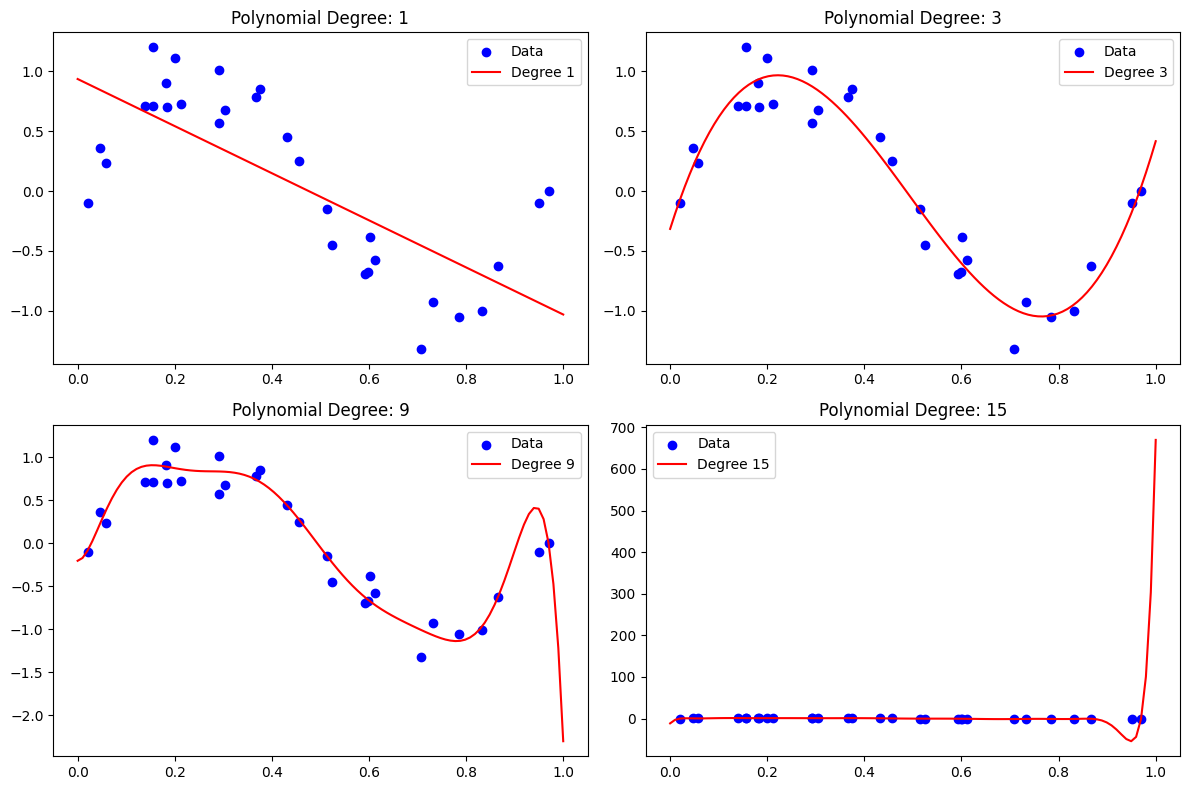

In [452]:
import matplotlib . pyplot as plt

degrees = [1, 3, 9, 15]

plt.figure(figsize=(12, 8))

for i, degree in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(degree), 
                          LinearRegression())
    model.fit(X_train, y_train)

    X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
    y_plot = model.predict(X_plot)

    plt.subplot(2, 2, i + 1)
    plt.scatter(X, y, color ='blue', label='Data')
    plt.plot(X_plot, y_plot, color='red', label = f'Degree {degree}')
    plt.title(f'Polynomial Degree: {degree}')
    plt.legend()
plt.tight_layout()

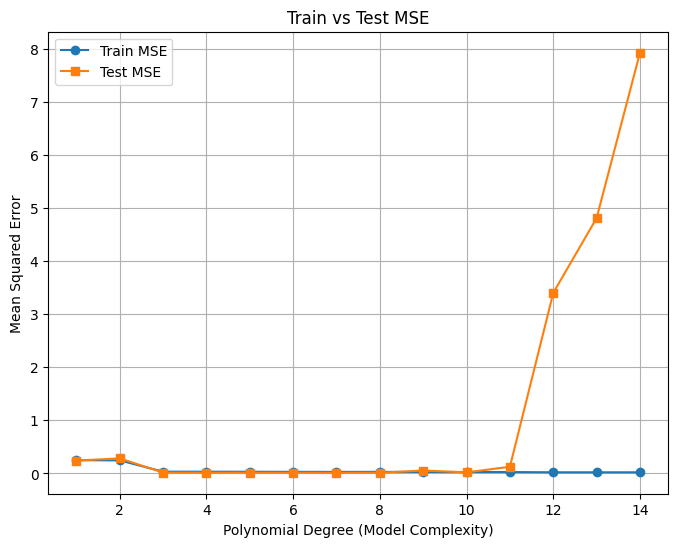

In [453]:
from sklearn.metrics import mean_squared_error

degrees = range(1, 15)

train_mse = []
test_mse = []

for degree in degrees:
    
    model = make_pipeline(PolynomialFeatures(degree),
                          LinearRegression())

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))

plt.figure(figsize=(8,6))

plt.plot(degrees, train_mse, marker='o', label='Train MSE')
plt.plot(degrees, test_mse, marker='s', label='Test MSE')

plt.xlabel("Polynomial Degree (Model Complexity)")
plt.ylabel("Mean Squared Error")
plt.title("Train vs Test MSE")
plt.legend()
plt.grid(True)

plt.show()

## Yeu cau 3

In [454]:
def plot_n(n):
    X = np.sort(np.random.rand(n, 1), axis=0)
    y = np.sin(2 * np.pi * X).ravel() + np.random.normal(0, 0.2, n)

    X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2)
    degrees = [1, 3, 9, 15]

    plt.figure(figsize=(12, 8))

    for i, degree in enumerate(degrees):
        model = make_pipeline(PolynomialFeatures(degree), 
                            LinearRegression())
        model.fit(X_train, y_train)

        X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
        y_plot = model.predict(X_plot)

        plt.subplot(2, 2, i + 1)
        plt.scatter(X, y, color ='blue', label='Data')
        plt.plot(X_plot, y_plot, color='red', label = f'Degree {degree}')
        plt.title(f'Polynomial Degree: {degree}')
        plt.legend()
    plt.tight_layout()

In [455]:
def mse_n():
    num_p = [15, 30, 200]

    plt.figure(figsize=(8,6))
    for i, n in enumerate(num_p):
        X = np.sort(np.random.rand(n, 1), axis=0)
        y = np.sin(2 * np.pi * X).ravel() + np.random.normal(0, 0.2, n)

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

        degrees = range(1, 15)

        train_mse = []
        test_mse = []

        for degree in degrees:

            model = make_pipeline(PolynomialFeatures(degree),
                                  LinearRegression())

            model.fit(X_train, y_train)

            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)

            train_mse.append(mean_squared_error(y_train, y_train_pred))
            test_mse.append(mean_squared_error(y_test, y_test_pred))

        plt.subplot(3, 1, i + 1)

        plt.plot(degrees, train_mse, marker='o', label='Train MSE')
        plt.plot(degrees, test_mse, marker='s', label='Test MSE')

        plt.xlabel("P")
        plt.ylabel("MSE")
        plt.title(f"n = {n}")
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

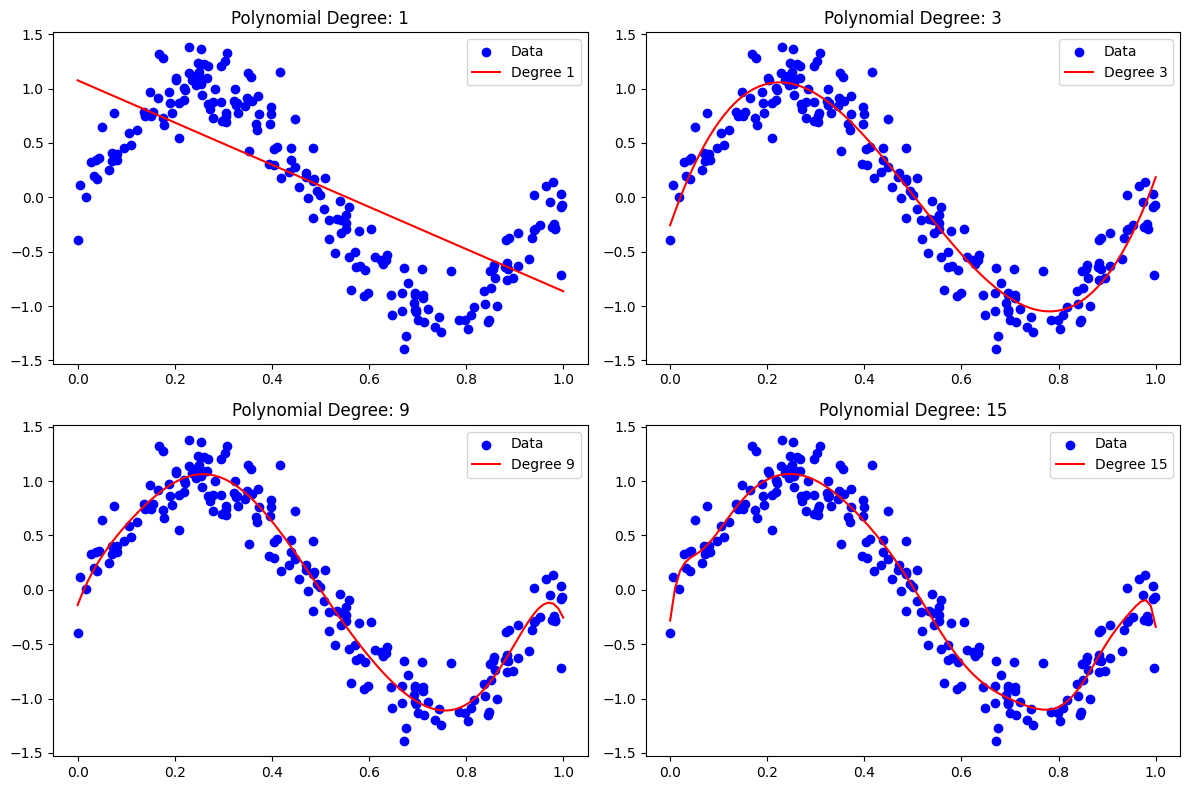

In [456]:
plot_n(200)

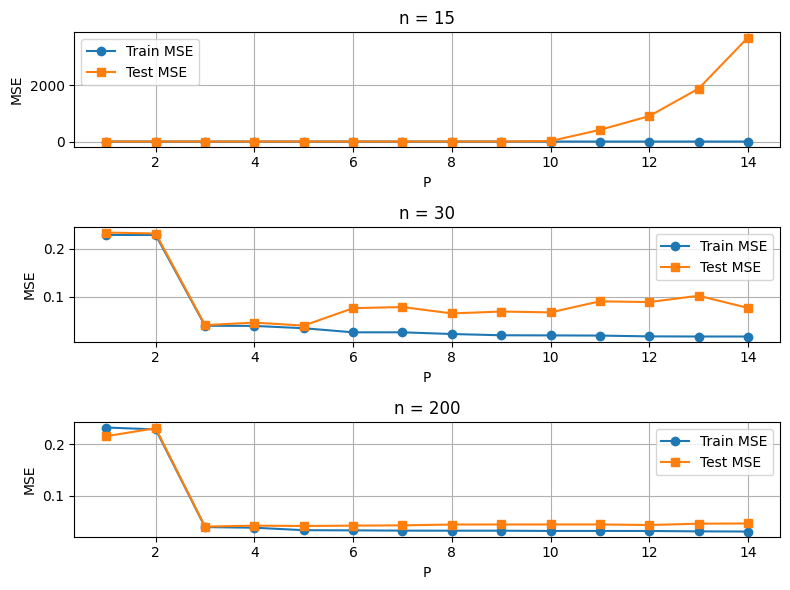

In [457]:
mse_n()

# Phan II

In [458]:
import pandas as pd

data = pd.read_csv('abalone.csv')
data.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [459]:
data = pd.get_dummies(data, columns=['Sex'], dtype=float)
data.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Sex_F,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,0.0,0.0,1.0
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,0.0,0.0,1.0
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,1.0,0.0,0.0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,0.0,0.0,1.0
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,0.0,1.0,0.0


In [460]:
data = data.dropna()
data['Rings'] = data['Rings'].astype('float64')

In [461]:
data.isna().sum()

Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
Sex_F             0
Sex_I             0
Sex_M             0
dtype: int64

In [462]:
data.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Sex_F,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15.0,0.0,0.0,1.0
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7.0,0.0,0.0,1.0
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9.0,1.0,0.0,0.0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10.0,0.0,0.0,1.0
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7.0,0.0,1.0,0.0


In [463]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3661 entries, 0 to 4176
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Length          3661 non-null   float64
 1   Diameter        3661 non-null   float64
 2   Height          3661 non-null   float64
 3   Whole weight    3661 non-null   float64
 4   Shucked weight  3661 non-null   float64
 5   Viscera weight  3661 non-null   float64
 6   Shell weight    3661 non-null   float64
 7   Rings           3661 non-null   float64
 8   Sex_F           3661 non-null   float64
 9   Sex_I           3661 non-null   float64
 10  Sex_M           3661 non-null   float64
dtypes: float64(11)
memory usage: 343.2 KB


In [464]:
X = data[['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight', 'Sex_F', 'Sex_I', 'Sex_M']].values
y = data['Rings'].values

In [465]:
print(np.isnan(X).sum(axis=0)) 

print(np.isinf(X).sum(axis=0))

[0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0]


In [466]:
print(X.shape)

(3661, 10)


In [467]:
def scaled(X):
    X_scaled = (X - X.min())/(X.max() - X.min())
    return X_scaled

In [468]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test = scaled(X_train), scaled(X_test)
y_train, y_test = scaled(y_train), scaled(y_test)

In [469]:
def plot_learning_curve(losses):
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(losses)), losses, label='Training Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Learning Curve')
    plt.legend()
    plt.grid()
    plt.show()

In [470]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, epochs=1000, bias=True, batch_size=32, shuffle=True):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = bias
        self.shuffle = shuffle
        self.batch_size = batch_size

    def predict(self, X):
        y_pred = np.dot(X, self.weights.T)
        return y_pred

    def loss_function(self, y_true, y_pred):
        S = np.sum((y_true - y_pred) ** 2)
        mse = S/len(y_true)
        return mse

    def gradient(self, X, y):
        y_pred = self.predict(X)
        dw = -(2/len(y))*np.dot(X.T, (y - y_pred))
        return dw
    
    def batch_generator(self, X, y):
        if self.shuffle:
            idx = np.random.permutation(len(y))
            X, y = X[idx], y[idx]

        for i in range(0, len(y), self.batch_size):
            yield X[i:i+self.batch_size], y[i:i+self.batch_size]


    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        losses = []
        for epoch in range(self.epochs):
            for X_batch, y_batch in self.batch_generator(X, y):
                dw = self.gradient(X_batch, y_batch)
                self.weights -= self.lr * dw

                y_pred = self.predict(X_batch)
                loss = self.loss_function(y_batch, y_pred)
            losses.append(loss)
            if epoch % 100 == 0:
                print(f'Epoch {epoch}, Loss {loss}')

        return losses

Epoch 0, Loss 0.09331239113133925
Epoch 100, Loss 0.011887668871674572
Epoch 200, Loss 0.01123034227532858
Epoch 300, Loss 0.010803240568340776
Epoch 400, Loss 0.010488643110966011
Epoch 500, Loss 0.010246320338336244
Epoch 600, Loss 0.010055221834925984
Epoch 700, Loss 0.009901550209684858
Epoch 800, Loss 0.00977550645138832
Epoch 900, Loss 0.009669966198063245


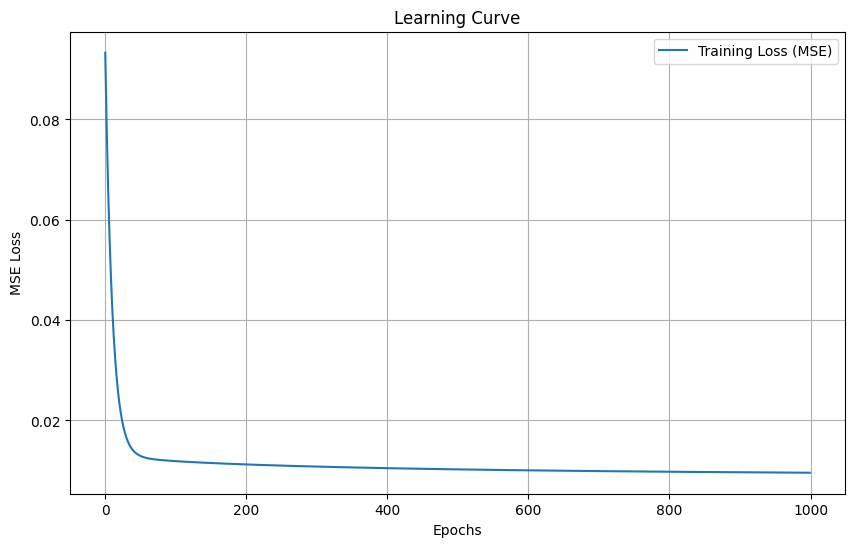

In [471]:
model_linear = LinearRegression(learning_rate=0.1, epochs=1000, 
                        batch_size=X_train.size)

losses = model_linear.fit(X_train, y_train)

plot_learning_curve(losses)

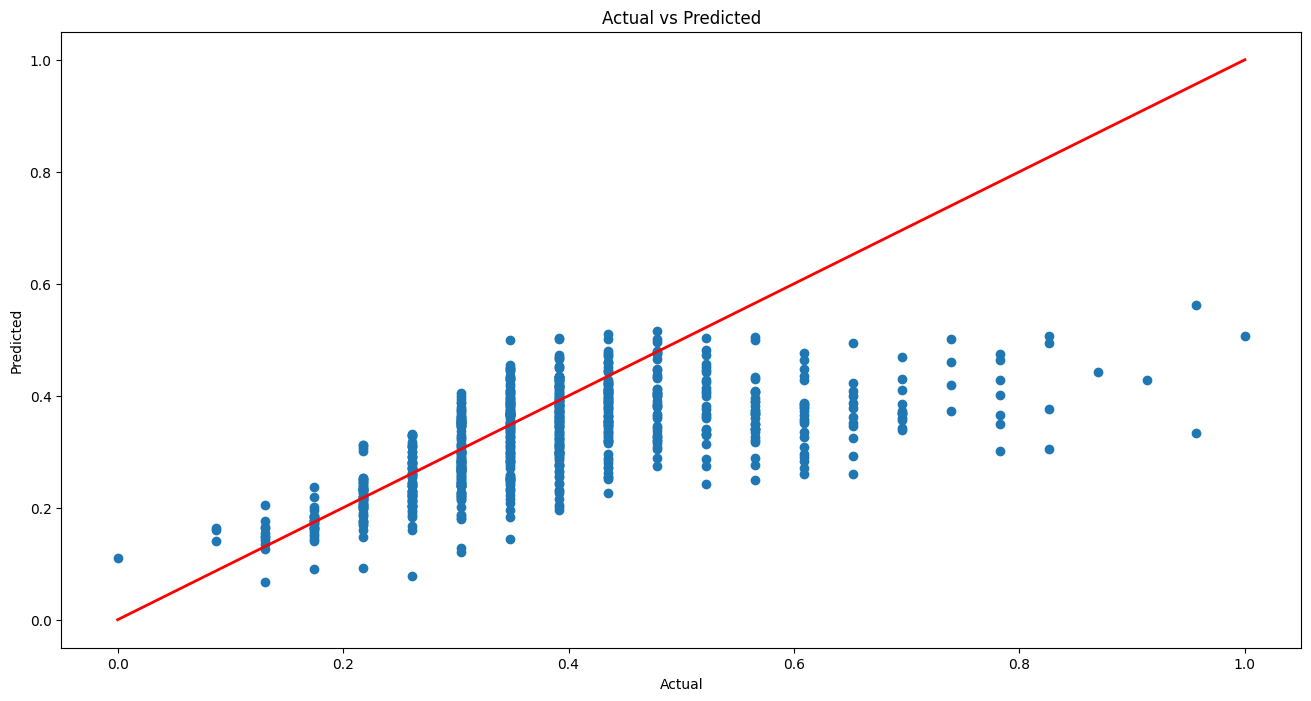

In [472]:
plt.figure(figsize=(16,8))

y_pred = model_linear.predict(X_test)
plt.scatter(y_test, y_pred)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linewidth=2, color='r')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [473]:
class RidgeRegression(LinearRegression):
    def __init__(self, learning_rate=0.01, epochs=1000, bias=True, lambda_=0.1,  batch_size=32, shuffle=True):
        super().__init__(learning_rate, epochs, bias, batch_size=batch_size, shuffle=shuffle)
        self.lambda_ = lambda_

    def loss_function(self, y_true, y_pred):
        return super().loss_function(y_true, y_pred) + self.lambda_ * np.sum(self.weights**2)

    def gradient(self, X, y):
        grad = super().gradient(X, y)
        grad += 2*self.lambda_*self.weights
        return grad

Epoch 0, Loss 0.09332113849076967
Epoch 100, Loss 0.01555135070310386
Epoch 200, Loss 0.015183476855454832
Epoch 300, Loss 0.01502440788653425
Epoch 400, Loss 0.014946088274933676
Epoch 500, Loss 0.014905716492529262
Epoch 600, Loss 0.014884403676783696
Epoch 700, Loss 0.0148729295971364
Epoch 800, Loss 0.014866628553028276
Epoch 900, Loss 0.01486309585609792


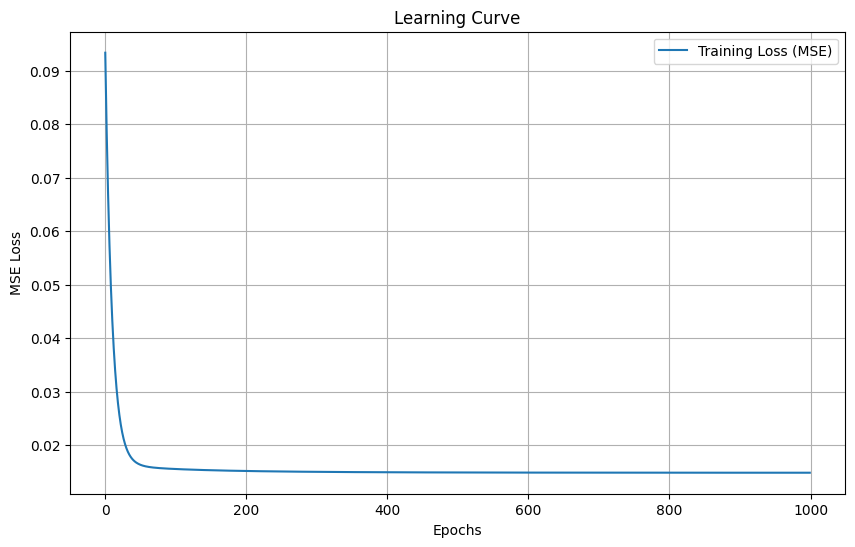

In [474]:
model_ridge = RidgeRegression(learning_rate=0.1, epochs=1000, 
                        batch_size=X_train.size, lambda_=0.01)

losses = model_ridge.fit(X_train, y_train)

plot_learning_curve(losses)

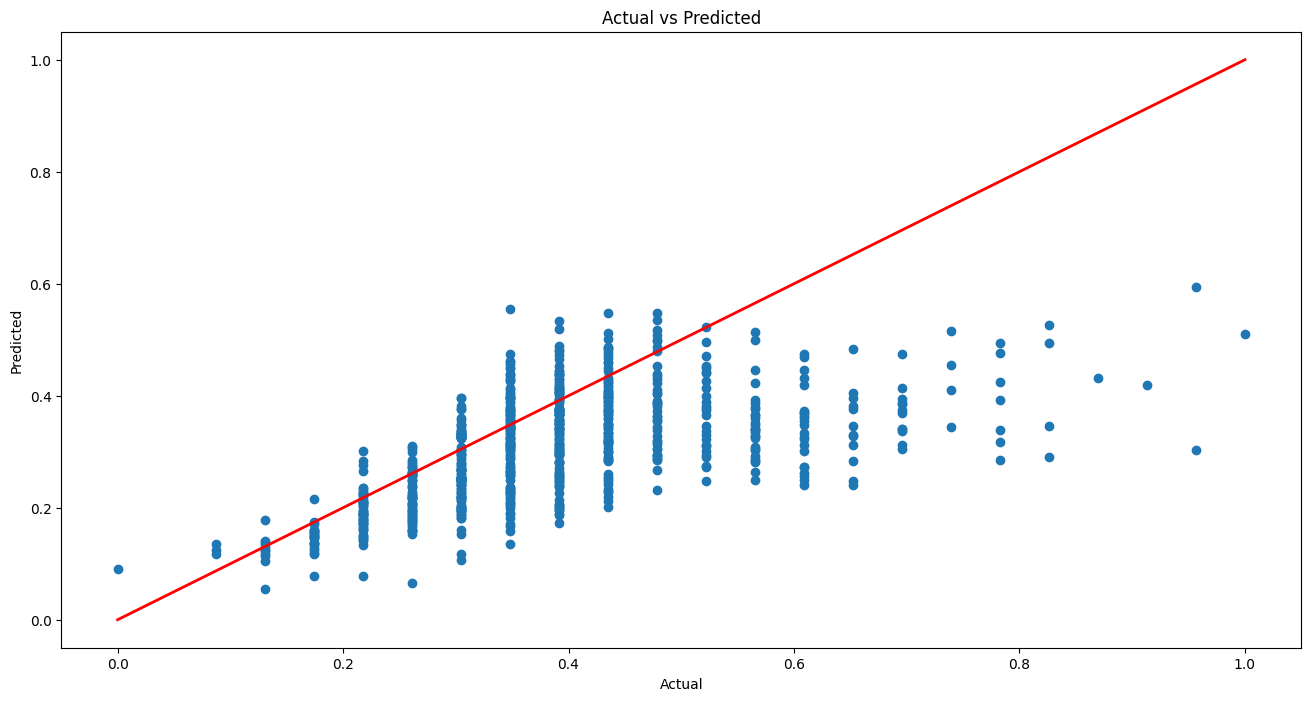

In [475]:
plt.figure(figsize=(16,8))

y_pred = model_ridge.predict(X_test)
plt.scatter(y_test, y_pred)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linewidth=2, color='r')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

Epoch 0, Loss 0.10097223780220295
Epoch 100, Loss 0.045728460874634363
Epoch 200, Loss 0.025041268895001
Epoch 300, Loss 0.017238339816297913
Epoch 400, Loss 0.01424424626213082
Epoch 500, Loss 0.013049306038636622
Epoch 600, Loss 0.012531259751852871
Epoch 700, Loss 0.01227115637136555
Epoch 800, Loss 0.012112187712924181
Epoch 900, Loss 0.011995312922064422
Epoch 0, Loss 0.10097311253814599
Epoch 100, Loss 0.05415041143304073
Epoch 200, Loss 0.04242665163320862
Epoch 300, Loss 0.03947035279414629
Epoch 400, Loss 0.03871223061914922
Epoch 500, Loss 0.03851014815303149
Epoch 600, Loss 0.03845169123426541
Epoch 700, Loss 0.03843212394318818
Epoch 800, Loss 0.0384241487899282
Epoch 900, Loss 0.0384202327937775
Epoch 0, Loss 0.10098098516163335
Epoch 100, Loss 0.08439582558089012
Epoch 200, Loss 0.08428886925656436
Epoch 300, Loss 0.08428817520827077
Epoch 400, Loss 0.08428817063617461
Epoch 500, Loss 0.08428817060496921
Epoch 600, Loss 0.08428817060473912
Epoch 700, Loss 0.08428817060473

/home/anhh/miniconda3/envs/face_env/lib/python3.8/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_375539/338506702.py:7: RuntimeWarning: overflow encountered in scalar multiply
  return super().loss_function(y_true, y_pred) + self.lambda_ * np.sum(self.weights**2)
/tmp/ipykernel_375539/1423275360.py:15: RuntimeWarning: overflow encountered in square
  S = np.sum((y_true - y_pred) ** 2)
/tmp/ipykernel_375539/338506702.py:7: RuntimeWarning: overflow encountered in square
  return super().loss_function(y_true, y_pred) + self.lambda_ * np.sum(self.weights**2)
/tmp/ipykernel_375539/338506702.py:11: RuntimeWarning: overflow encountered in multiply
  grad += 2*self.lambda_*self.weights


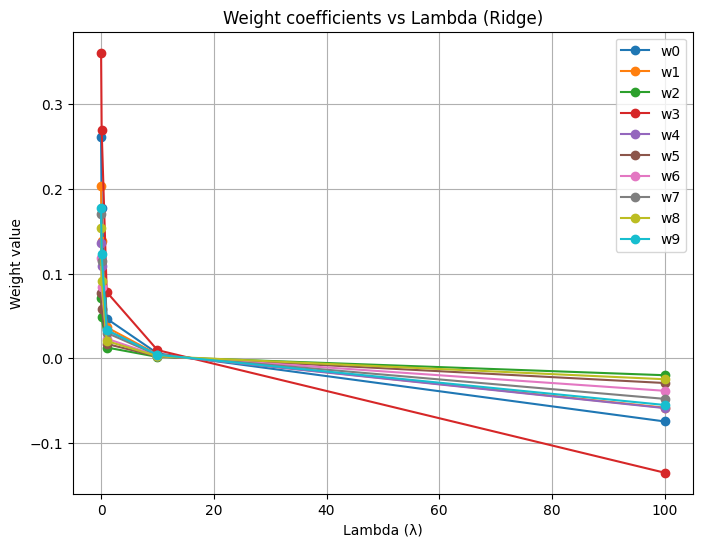

In [476]:
lambda_list = [0, 0.1, 1, 10, 100, 1000]

weights = []

for ld in lambda_list:
    model_ridge = RidgeRegression(
        learning_rate=0.01,
        epochs=1000,
        batch_size=X_train.shape[0],
        lambda_=ld
    )

    model_ridge.fit(X_train, y_train)
    weights.append(model_ridge.weights)  

weights = np.array(weights)  

plt.figure(figsize=(8,6))

for j in range(weights.shape[1]):
    plt.plot(lambda_list, weights[:, j], marker='o', label=f'w{j}')

# plt.xscale('log') 
plt.xlabel('Lambda (λ)')
plt.ylabel('Weight value')
plt.title('Weight coefficients vs Lambda (Ridge)')
plt.legend()
plt.grid()
plt.show()

In [477]:
class LassoRegression(LinearRegression):
    def __init__(self, learning_rate=0.01, epochs=1000, bias=True, lambda_=0.1,  batch_size=32, shuffle=True):
        super().__init__(learning_rate, epochs, bias, batch_size=batch_size, shuffle=shuffle)
        self.lambda_ = lambda_
    
    def loss_function(self, y_true, y_pred):
        return super().loss_function(y_true, y_pred) + self.lambda_ * np.sum(np.abs(self.weights))
    def gradient(self, X, y):
        grad = super().gradient(X, y)
        grad += self.lambda_ * np.sign(self.weights)
        return grad

Epoch 0, Loss 0.10105428766282872
Epoch 100, Loss 0.055568600604794925
Epoch 200, Loss 0.03849688096266496
Epoch 300, Loss 0.032013175870750435
Epoch 400, Loss 0.029476054639318877
Epoch 500, Loss 0.028410948580482466
Epoch 600, Loss 0.02789570382331088
Epoch 700, Loss 0.027586558571979475
Epoch 800, Loss 0.02735526383652994
Epoch 900, Loss 0.027153887397197755


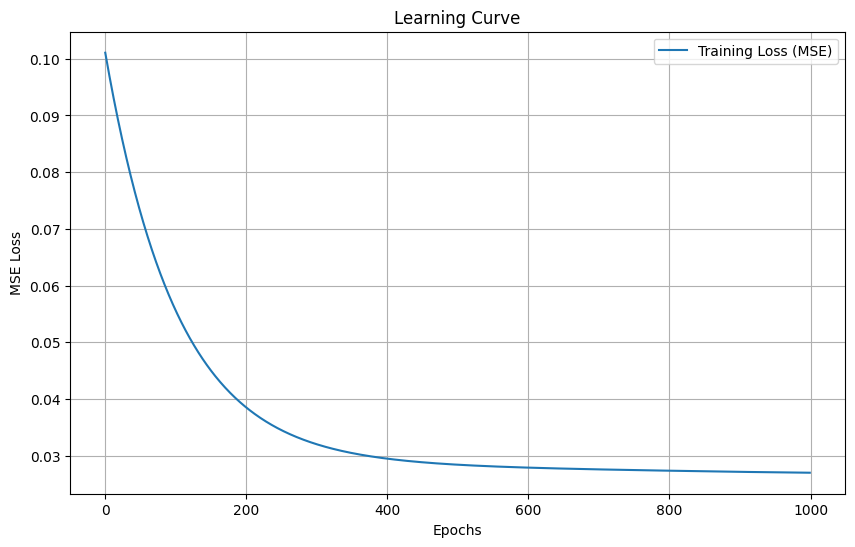

In [478]:
model_lasso = LassoRegression(learning_rate=0.01, epochs=1000, 
                        batch_size=X_train.size, lambda_=0.01)

losses = model_lasso.fit(X_train, y_train)

plot_learning_curve(losses)

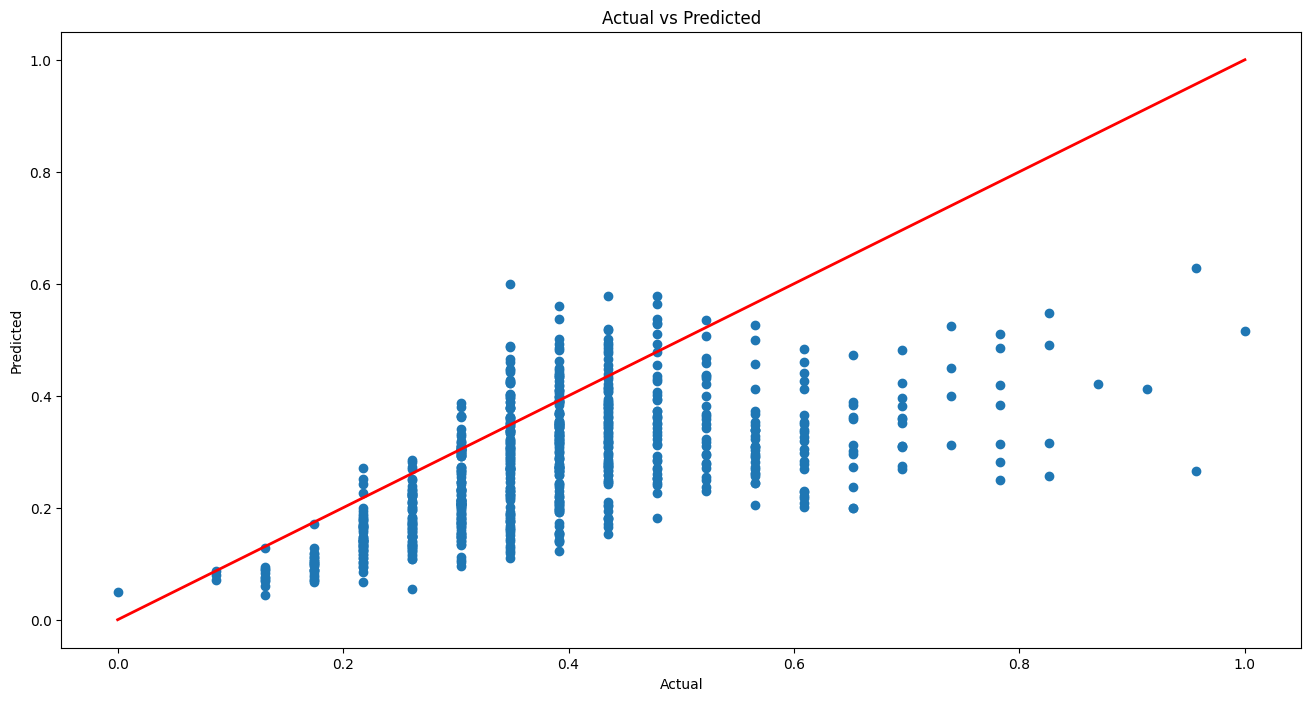

In [479]:
plt.figure(figsize=(16,8))

y_pred = model_lasso.predict(X_test)
plt.scatter(y_test, y_pred)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linewidth=2, color='r')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [480]:
model_lasso = LassoRegression(
        learning_rate=0.01,
        epochs=1000,
        batch_size=X_train.shape[0],
        lambda_=0.01
)

weights = []

model_lasso.fit(X_train, y_train)
weights.append(model_lasso.weights)  
weights = np.array(weights)

print(weights)

Epoch 0, Loss 0.10105428766282873
Epoch 100, Loss 0.05556860060479493
Epoch 200, Loss 0.038496880962664966
Epoch 300, Loss 0.03201317587075044
Epoch 400, Loss 0.029476054639318877
Epoch 500, Loss 0.028410948580482466
Epoch 600, Loss 0.02789570382331088
Epoch 700, Loss 0.02758655857197948
Epoch 800, Loss 0.02735526383652994
Epoch 900, Loss 0.027153887397197755
[[2.46809622e-01 1.70851156e-01 2.59206093e-06 4.05175186e-01
  9.89166578e-02 7.90125724e-03 5.98739870e-02 1.23889693e-01
  9.79777728e-02 1.35770110e-01]]


Epoch 0, Loss 0.10097223780220294
Epoch 100, Loss 0.045728460874634363
Epoch 200, Loss 0.02504126889500099
Epoch 300, Loss 0.01723833981629791
Epoch 400, Loss 0.01424424626213082
Epoch 500, Loss 0.013049306038636622
Epoch 600, Loss 0.012531259751852871
Epoch 700, Loss 0.012271156371365546
Epoch 800, Loss 0.012112187712924181
Epoch 900, Loss 0.011995312922064419
Epoch 0, Loss 0.10179273640846072
Epoch 100, Loss 0.09457922387348007
Epoch 200, Loss 0.09015348110263544
Epoch 300, Loss 0.08734876924096406
Epoch 400, Loss 0.08552662320546615
Epoch 500, Loss 0.08440526687881247
Epoch 600, Loss 0.08368283262742365
Epoch 700, Loss 0.08323629494524296
Epoch 800, Loss 0.08297214370130383
Epoch 900, Loss 0.08274817283596558
Epoch 0, Loss 0.10917722386478079
Epoch 100, Loss 0.15353633877348505
Epoch 200, Loss 0.1554443959512063
Epoch 300, Loss 0.16507440034978965
Epoch 400, Loss 0.15558853354161092
Epoch 500, Loss 0.16279949431792556
Epoch 600, Loss 0.1568923825469004
Epoch 700, Loss 0.142498156894

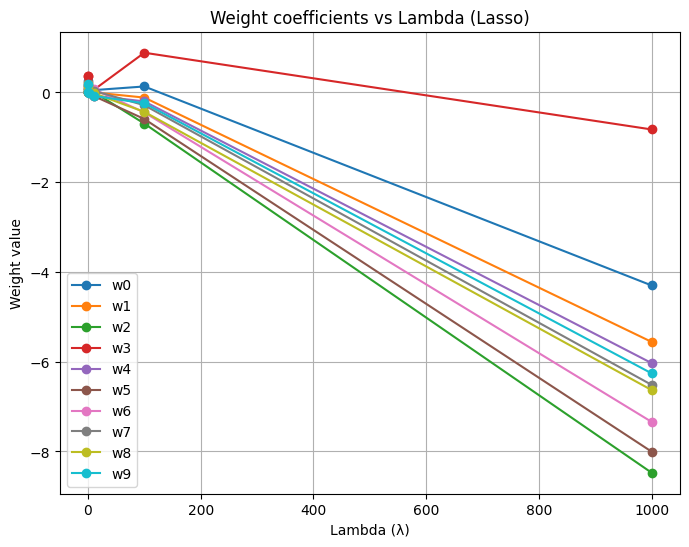

In [481]:
lambda_list = [0, 0.1, 1, 10, 100, 1000]

weights = []

for ld in lambda_list:
    model_lasso = LassoRegression(
        learning_rate=0.01,
        epochs=1000,
        batch_size=X_train.shape[0],
        lambda_=ld
    )

    model_lasso.fit(X_train, y_train)
    weights.append(model_lasso.weights)  

weights = np.array(weights)  

plt.figure(figsize=(8,6))

for j in range(weights.shape[1]):
    plt.plot(lambda_list, weights[:, j], marker='o', label=f'w{j}')

# plt.xscale('log') 
plt.xlabel('Lambda (λ)')
plt.ylabel('Weight value')
plt.title('Weight coefficients vs Lambda (Lasso)')
plt.legend()
plt.grid()
plt.show()

# III. Model Selection

In [482]:
from sklearn . model_selection import cross_val_score
from sklearn . linear_model import LinearRegression
from sklearn . metrics import mean_squared_error , mean_absolute_error , r2_score

model = LinearRegression()
scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')

rmse = np.sqrt(-scores)
print(f'RMSE : {np.mean(rmse)}')

scores = cross_val_score(model, X, y, cv=5, scoring ='neg_mean_absolute_error')

mae = -scores
print(f'MAE : {np.mean(mae)}')
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
r2 = scores
print(f'R2: {np.mean(r2)}')

RMSE : 2.2605514184002016
MAE : 1.6462778472910409
R2: 0.4187936265013451


In [483]:
def evaluate(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    return mse, rmse, mae, r2

In [484]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso, Ridge

print(cross_val_score(Lasso(), X, y, cv=5))

[-0.18872833 -0.76659659 -0.04406292 -0.01036306 -0.0375445 ]


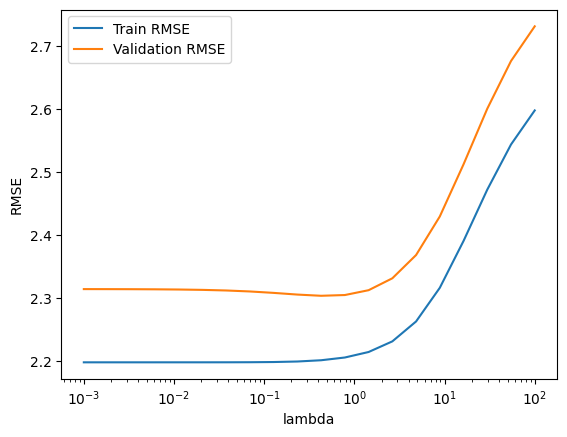

In [485]:
from sklearn.model_selection import validation_curve

param_range = np.logspace(-3, 2, 20)
train_scores, val_scores = validation_curve(
    Ridge(), X, y, param_name='alpha',
    param_range=param_range, cv=5,
    scoring='neg_mean_squared_error'
)

# Tinh trung binh va do lech chuan
train_mean = np.sqrt(-train_scores.mean(axis=1))
val_mean = np.sqrt(-val_scores.mean(axis=1))

# Ve do thi
plt.semilogx(param_range, train_mean, label='Train RMSE')
plt.semilogx(param_range, val_mean, label='Validation RMSE')
plt.xlabel('lambda')
plt.ylabel('RMSE')
plt.legend()

# IV. Đọc thêm

In [486]:
class KernelRidgeRegression :
    def __init__(self, learning_rate=0.0001, epochs=1000, lambda_=1, gamma=0.01):
        self.lr = learning_rate
        self.epochs = epochs
        self.lambda_ = lambda_
        self.gamma = gamma
        self.alpha = None
        self.K = None
        self.X_train = None

    def kernel_function(self, X1, X2):
        X1 = np.array(X1, dtype=np.float64)
        X2 = np.array(X2, dtype=np.float64)
        K = np.zeros((X1.shape[0], X2.shape[0]))
        for i, x1 in enumerate(X1):
            for j, x2 in enumerate(X2):
                K[i, j] = np.exp(-self.gamma * (np.linalg.norm(x1 - x2) ** 2))
        return K

    def predict(self, X):
        K = self.kernel_function(X, self.X_train)
        return np.dot(K, self.alpha)

    def loss_function(self, y):
        K = self.K
        n = len(y)
        return 1/n*np.sum((y - np.dot(K, self.alpha))**2) + self.lambda_*np.sum(self.alpha**2)

    def gradient(self, y):
        K = self.K
        error = y - np.dot(K, self.alpha)
        n = len(y)
        grad = -2/n * np.dot(K, error) + 2 * self.lambda_ * self.alpha
        return grad
    
    def fit(self, X, y):
        self.X_train = X
        self.K = self.kernel_function(self.X_train, self.X_train)
        self.alpha = np.zeros(len(X))
        
        for i in range(self.epochs):
            grad = self.gradient(y)
            self.alpha -= self.lr * grad
            if i % 100 == 0:
                print(f'Loss : {self.loss_function(y)}')

In [487]:
model = KernelRidgeRegression(lambda_=0.01, gamma=1)

model.fit(X_train, y_train)

Loss : 0.04953183740068789
Loss : 0.011725327686322007
Loss : 0.010696112345799133
Loss : 0.010314998749802377
Loss : 0.01016167074064872
Loss : 0.010089949212656065
Loss : 0.010048695839937895
Loss : 0.010019815199943567
Loss : 0.00999675635543771
Loss : 0.009977036886365129


In [488]:
y_pred = model.predict(X_test)
mse, rmse, mae, r2 = evaluate(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

Mean Squared Error: 0.02216787662110386
Root Mean Squared Error: 0.14888880623171058
Mean Absolute Error: 0.10339569927680421
R-squared: -0.11972113486385783


In [489]:
from sklearn.kernel_ridge import KernelRidge

model = KernelRidge(alpha=0.01, kernel='rbf', gamma=0.15)

# Fit model
model.fit(X_train, y_train)


KernelRidge(alpha=0.01, gamma=0.15, kernel='rbf')

In [490]:
y_pred = model.predict(X_test)
mse, rmse, mae, r2 = evaluate(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

Mean Squared Error: 0.014701009450588522
Root Mean Squared Error: 0.1212477193624215
Mean Absolute Error: 0.08898942906469018
R-squared: 0.25743763072073633
